In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [30]:
data_path = "/mnt/c/Users/tanbi/OneDrive/Documents/sn_bose/d04_text_station_5min_2026_01_01.txt"
print(os.path.exists(data_path))
data_df = pd.read_csv(data_path, header=None)
station_metadata_path  = '/mnt/c/Users/tanbi/Downloads/d04_text_meta_2025_10_16.txt'
print("station metadata path exits? ", os.path.exists(station_metadata_path))
st_mtdta_df = pd.read_csv(station_metadata_path, sep='\t')

columns_12 = ["timestamp", "station", "district", "freeway", "direction", "lane_type", 
           "station_length", "samples", "perc_obs", "total_flow", "avg_occupancy", 
           "avg_speed"]
rest_columns = [
    col
    for i in range(1, 9)
    for col in [
        f"lane_{i}_samples", 
        f"lane_{i}_flow", 
        f"lane_{i}_avg_occp", 
        f"lane_{i}_avg_speed", 
        f"lane_{i}_observed"        
    ]
]
data_df.columns = columns_12 + rest_columns


True
station metadata path exits?  True


In [31]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110240 entries, 0 to 1110239
Data columns (total 52 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   timestamp         1110240 non-null  str    
 1   station           1110240 non-null  int64  
 2   district          1110240 non-null  int64  
 3   freeway           1110240 non-null  int64  
 4   direction         1110240 non-null  str    
 5   lane_type         1110240 non-null  str    
 6   station_length    651456 non-null   float64
 7   samples           1110240 non-null  int64  
 8   perc_obs          1110240 non-null  int64  
 9   total_flow        900379 non-null   float64
 10  avg_occupancy     900379 non-null   float64
 11  avg_speed         650880 non-null   float64
 12  lane_1_samples    1110240 non-null  int64  
 13  lane_1_flow       884665 non-null   float64
 14  lane_1_avg_occp   884665 non-null   float64
 15  lane_1_avg_speed  650880 non-null   float64
 16  lane_1_obse

In [32]:
data_df.head()

,timestamp,station,district,freeway,direction,lane_type,station_length,samples,perc_obs,total_flow,...,lane_7_samples,lane_7_flow,lane_7_avg_occp,lane_7_avg_speed,lane_7_observed,lane_8_samples,lane_8_flow,lane_8_avg_occp,lane_8_avg_speed,lane_8_observed
0,01/01/2026 00:00:00,400000,4,101,S,ML,0.415,40,100,39.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,01/01/2026 00:00:00,400001,4,101,N,ML,0.265,50,0,85.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
2,01/01/2026 00:00:00,400002,4,101,S,ML,0.305,50,0,179.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,01/01/2026 00:00:00,400006,4,880,S,ML,0.340,40,100,92.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
4,01/01/2026 00:00:00,400007,4,101,N,ML,0.365,50,0,146.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


In [33]:
# types on lanes
data_df["lane_type"].value_counts()

lane_type
ML    650304
OR    263232
FR    180000
FF     16128
HV       576
Name: count, dtype: int64

### We have 5 Lanes type here.

In [34]:
data_df["timestamp"].value_counts()

timestamp
01/01/2026 00:00:00    3855
01/01/2026 00:05:00    3855
01/01/2026 00:10:00    3855
01/01/2026 00:15:00    3855
01/01/2026 00:20:00    3855
                       ... 
01/01/2026 23:35:00    3855
01/01/2026 23:40:00    3855
01/01/2026 23:45:00    3855
01/01/2026 23:50:00    3855
01/01/2026 23:55:00    3855
Name: count, Length: 288, dtype: int64

### For each 5 minutes -> we have 3855 data samples, from 3855 unique stations

In [8]:
# Condensing logic into a function for reuseability
def get_stations_near_roi(
    st_mtdta_df: pd.DataFrame,
    lat_min=37.353455, lat_max=37.378862,
    long_min=-121.931501, long_max=-121.888125,
    fwy_a=101, fwy_b=880, buffer=1.5
):
    """
    gets stations upstream and downstream of an interchanges in a region of interest
    """
    region_df = st_mtdta_df[
        (st_mtdta_df['Latitude']>=lat_min) & (st_mtdta_df['Latitude']<=lat_max) &
        (st_mtdta_df['Longitude']>=long_min) & (st_mtdta_df['Longitude']<=long_max)
    ].copy()
    
    print(len(region_df), " Number of stations in this region.") # 58 stations in this region

    # finding stations in interchange, simple approach using name discription
    interchange_rows_a = region_df[(region_df["Fwy"] == fwy_a) & (region_df["Name"].str.contains(str(fwy_b)))]
    interchange_rows_b = region_df[(region_df["Fwy"] == fwy_b) & (region_df["Name"].str.contains(str(fwy_a)))]
    
    min_a, max_a = interchange_rows_a["Abs_PM"].min(), interchange_rows_a["Abs_PM"].max()
    min_b, max_b = interchange_rows_b["Abs_PM"].min(), interchange_rows_b["Abs_PM"].max()
    
    # Main corridors
    ml_a = region_df[(region_df["Fwy"] == fwy_a) & (region_df['Type'] == "ML")]
    ml_b = region_df[(region_df["Fwy"] == fwy_b) & (region_df['Type'] == "ML")] 
    
    u_a_nb = ml_a[(ml_a['Dir'] == 'N') & (ml_a['Abs_PM'] >= min_a - buffer) & (ml_a['Abs_PM'] < min_a)].sort_values('Abs_PM', ascending=True)
    d_a_nb = ml_a[(ml_a['Dir'] == 'N') & (ml_a['Abs_PM'] > max_a) & (ml_a['Abs_PM'] <= max_a + buffer)].sort_values('Abs_PM', ascending=True)
    
    u_a_sb = ml_a[(ml_a['Dir'] == 'S') & (ml_a['Abs_PM'] > max_a) & (ml_a['Abs_PM'] <= max_a + buffer)].sort_values('Abs_PM', ascending=False)
    d_a_sb = ml_a[(ml_a['Dir'] == 'S') & (ml_a['Abs_PM'] >= min_a - buffer) & (ml_a['Abs_PM'] < min_a)].sort_values('Abs_PM', ascending=False)
    
    
    u_b_nb = ml_b[(ml_b["Dir"] == 'N') & (ml_b['Abs_PM'] >= min_b - buffer) & (ml_b['Abs_PM'] < min_b)].sort_values('Abs_PM', ascending=True)
    d_b_nb = ml_b[(ml_b["Dir"] == 'N') & (ml_b['Abs_PM'] > max_b) & (ml_b['Abs_PM'] <= max_b + buffer)].sort_values('Abs_PM', ascending=True)
    
    u_b_sb = ml_b[(ml_b["Dir"] == 'S') & (ml_b['Abs_PM'] > max_b) & (ml_b['Abs_PM'] <= max_b + buffer)].sort_values('Abs_PM', ascending=False)
    d_b_sb = ml_b[(ml_b["Dir"] == 'S') & (ml_b['Abs_PM'] >= min_b - buffer) & (ml_b['Abs_PM'] < min_b)].sort_values('Abs_PM', ascending=False)

    # 4. Package into an organized dictionary
    results = {
        f"{fwy_a}_NB_upstream": u_a_nb,
        f"{fwy_a}_NB_downstream": d_a_nb,
        f"{fwy_a}_SB_upstream": u_a_sb,
        f"{fwy_a}_SB_downstream": d_a_sb,
        f"{fwy_b}_NB_upstream": u_b_nb,
        f"{fwy_b}_NB_downstream": d_b_nb,
        f"{fwy_b}_SB_upstream": u_b_sb,
        f"{fwy_b}_SB_downstream": d_b_sb
    }

    return results

def param_mat(parameter: str, selected_ids: list, filtered_df: pd.DataFrame):
    filtered_param_mat = filtered_df.pivot(
        index='timestamp',
        columns='station',
        values=f"{parameter}"
    )
    filtered_param_mat = filtered_param_mat[selected_ids]
    return filtered_param_mat


In [17]:
lat_min = 37.3534550567675 
long_min = -121.93150052135863
lat_max = 37.378862007437284
long_max = -121.88812513240218

region_df = st_mtdta_df[
    (st_mtdta_df['Latitude']>=lat_min) & (st_mtdta_df['Latitude']<=lat_max) &
    (st_mtdta_df['Longitude']>=long_min) & (st_mtdta_df['Longitude']<=long_max)
].copy()

In [42]:
region_df

,ID,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
1,400001,101,N,4,85,68000.0,38.26,387.897,37.364085,-121.901149,0.265,ML,5,NB 880 rm-n-loop,DT697,L5-N-37-101-03826,998145,426518
14,400030,880,S,4,85,68000.0,3.64,3.640,37.359087,-121.906538,0.250,ML,4,N First St rm-s-loop,DT969,L4-S-37-880-00364,880130,421412
22,400045,880,N,4,85,68000.0,4.02,4.020,37.363402,-121.902233,0.300,ML,4,SB 101 rm-n-loop,DT974,L4-N-37-880-00402,998313,421007
60,400109,101,S,4,85,68000.0,37.61,387.283,37.362706,-121.889426,0.785,ML,4,N 13th St/Oakland Rd rm-s-diag,DT027,L4-S-37-101-03761,998139,424540
69,400122,880,N,4,85,68000.0,4.21,4.210,37.366140,-121.901132,0.240,ML,3,NB 101 rm-n-diag,DT975,L3-N-37-880-00421,998317,421012
223,400394,101,S,4,85,68000.0,38.35,388.023,37.364382,-121.902692,0.280,ML,5,SB 880 rm-s-loop,DT192,L5-S-37-101-03835,998147,427043
274,400479,880,S,4,85,68000.0,3.94,3.940,37.362439,-121.903211,0.245,ML,4,SB 101 rm-s-diag,DTA65,L4-S-37-880-00394,998311,421417
441,400760,101,N,4,85,68000.0,40.1,389.737,37.374628,-121.931055,0.530,ML,4,NB 87 rm-n-diag,DTB04,L4-N-37-101-04010,998153,422626
495,400863,101,N,4,85,68000.0,39.28,388.917,37.371809,-121.916550,0.430,ML,4,N 1st St rm-n-loop,DT699,L4-N-37-101-03928,998149,422614
515,400911,101,N,4,85,68000.0,39.59,389.227,37.372674,-121.922087,0.410,ML,4,Brokaw Rd rm-n-diag,DT713,L4-N-37-101-03959,998151,422620


In [41]:
region_df['Dir'].value_counts()

Dir
N    31
S    27
Name: count, dtype: int64

Plotting Space-Time Contours: Hwy 87 N (5 Stations)


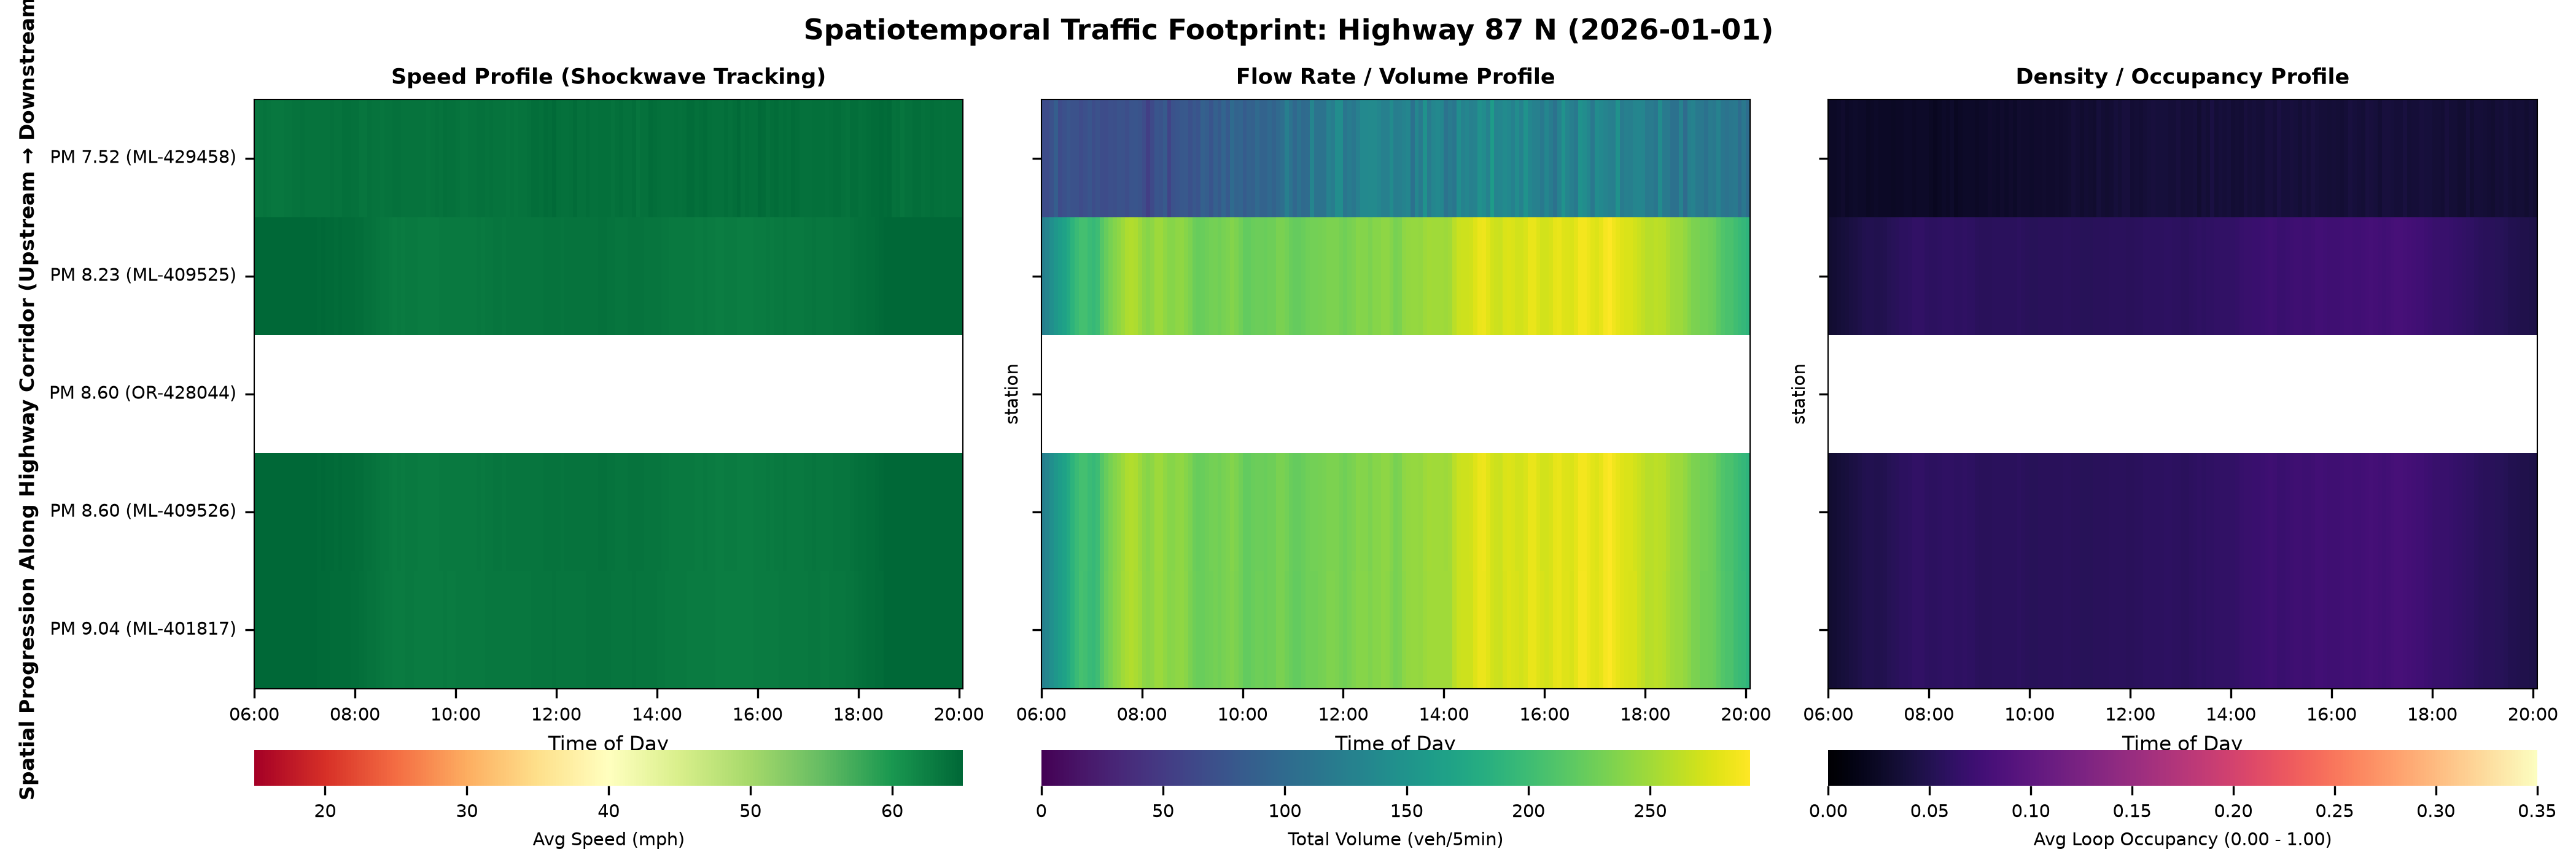

Plotting Space-Time Contours: Hwy 87 S (6 Stations)


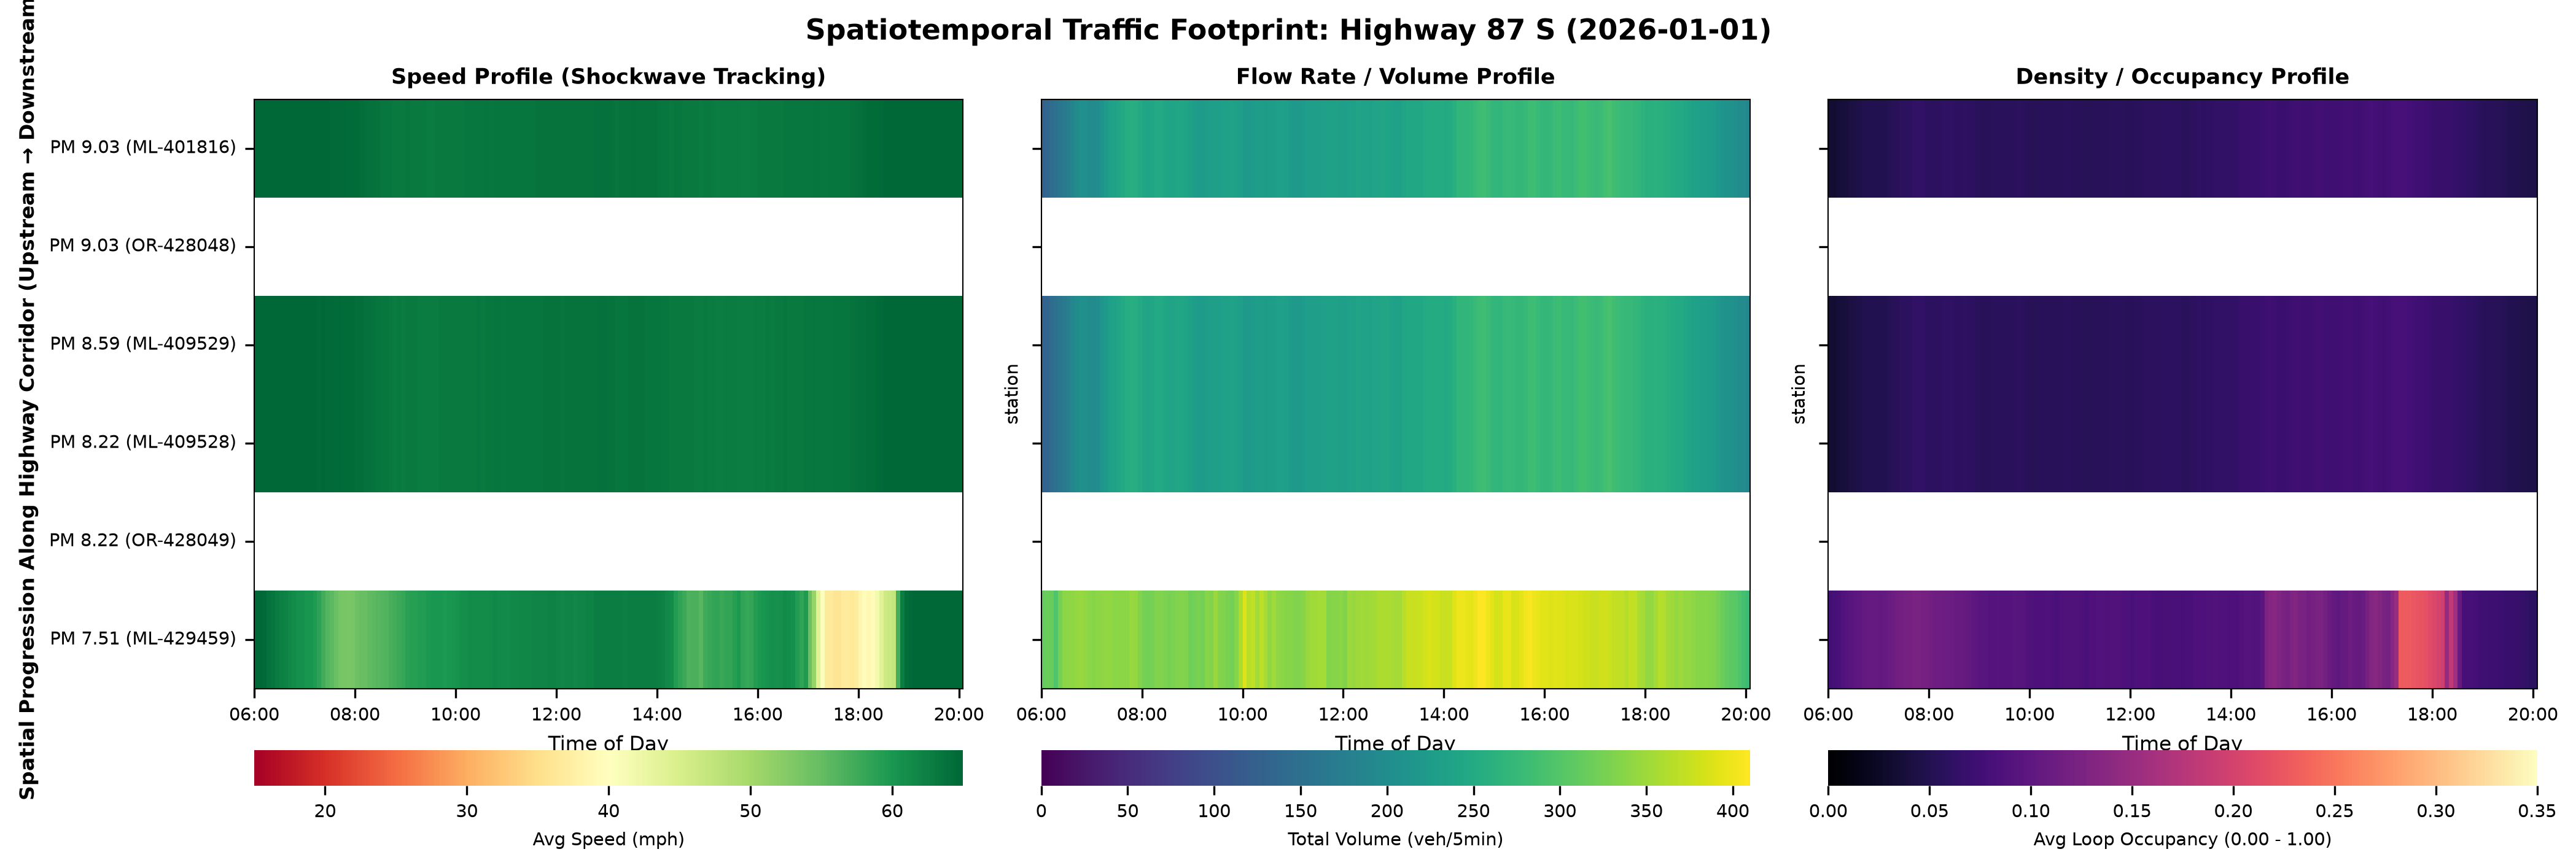

Plotting Space-Time Contours: Hwy 101 N (14 Stations)


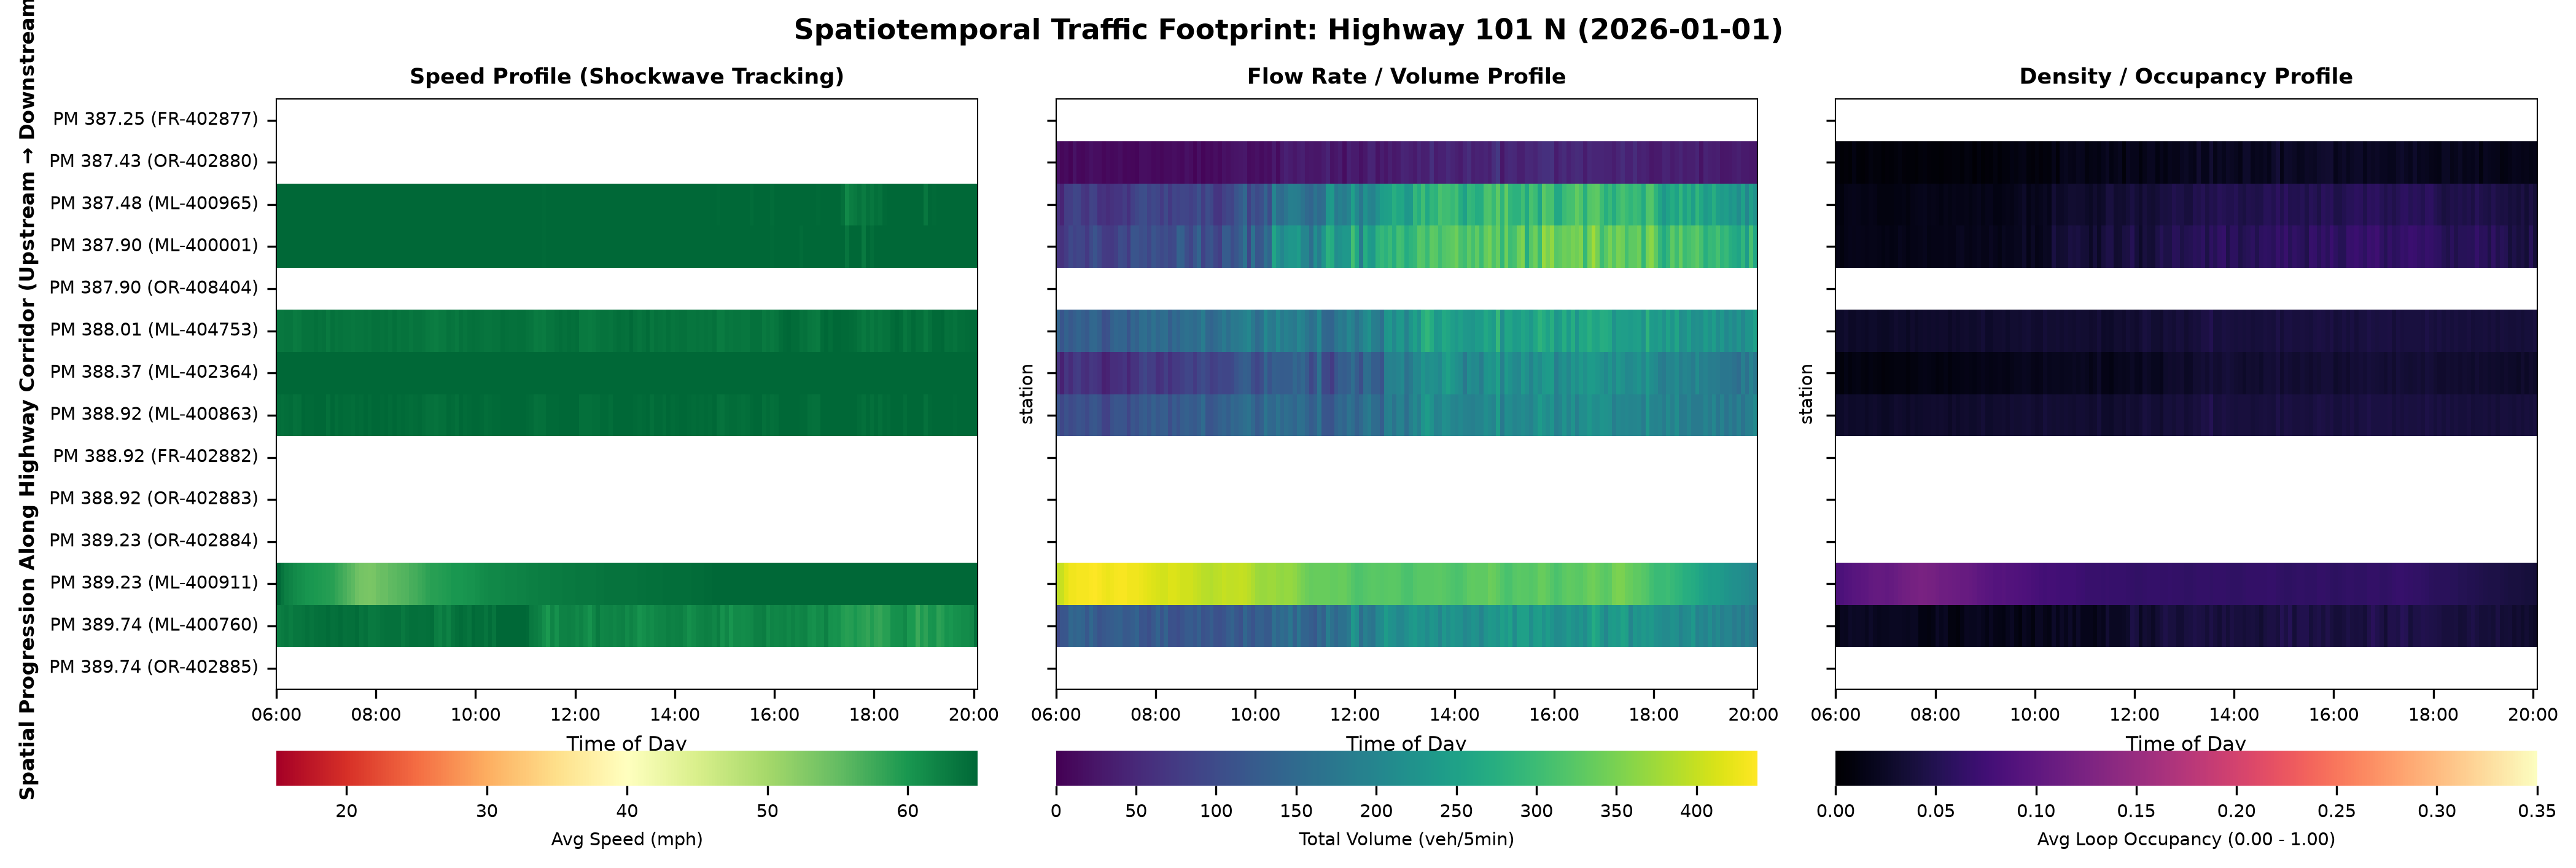

Plotting Space-Time Contours: Hwy 101 S (9 Stations)


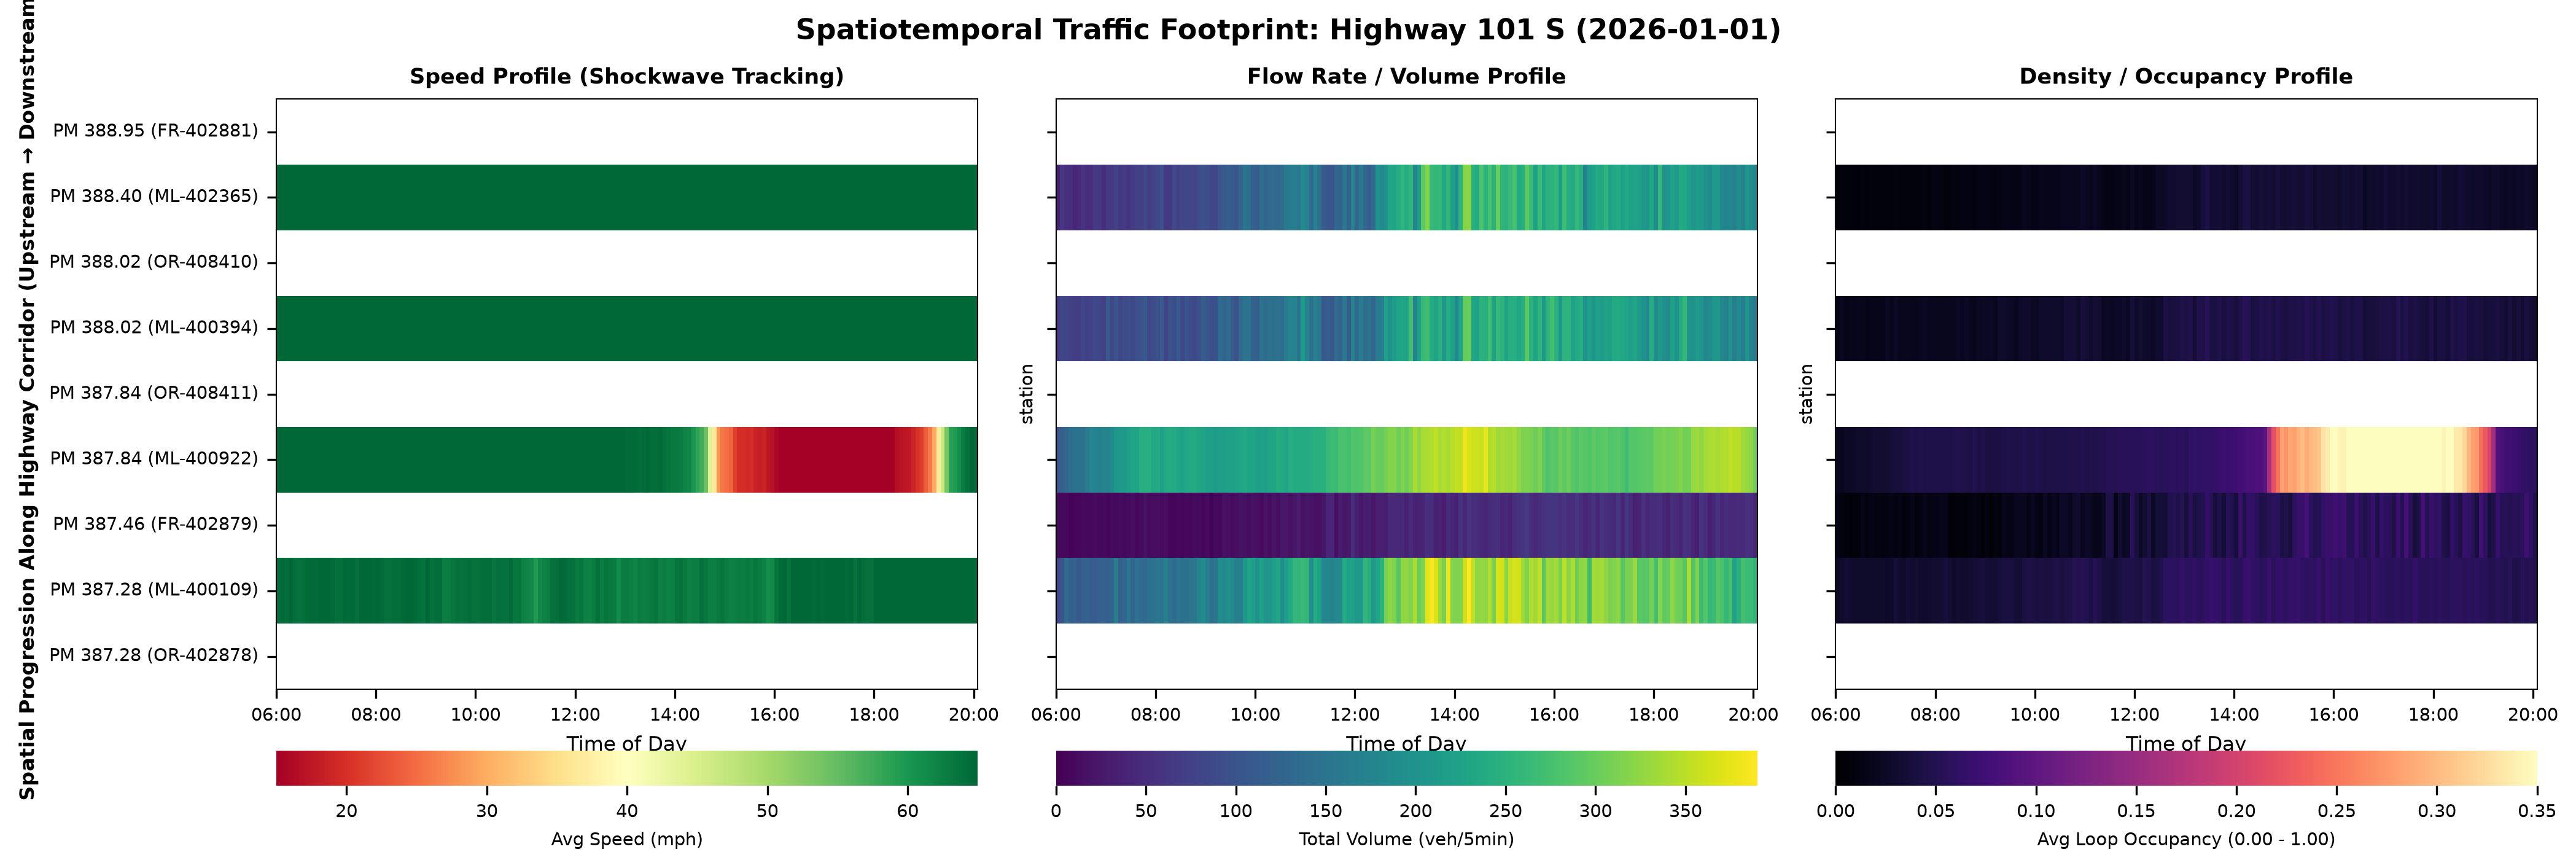

Plotting Space-Time Contours: Hwy 880 N (12 Stations)


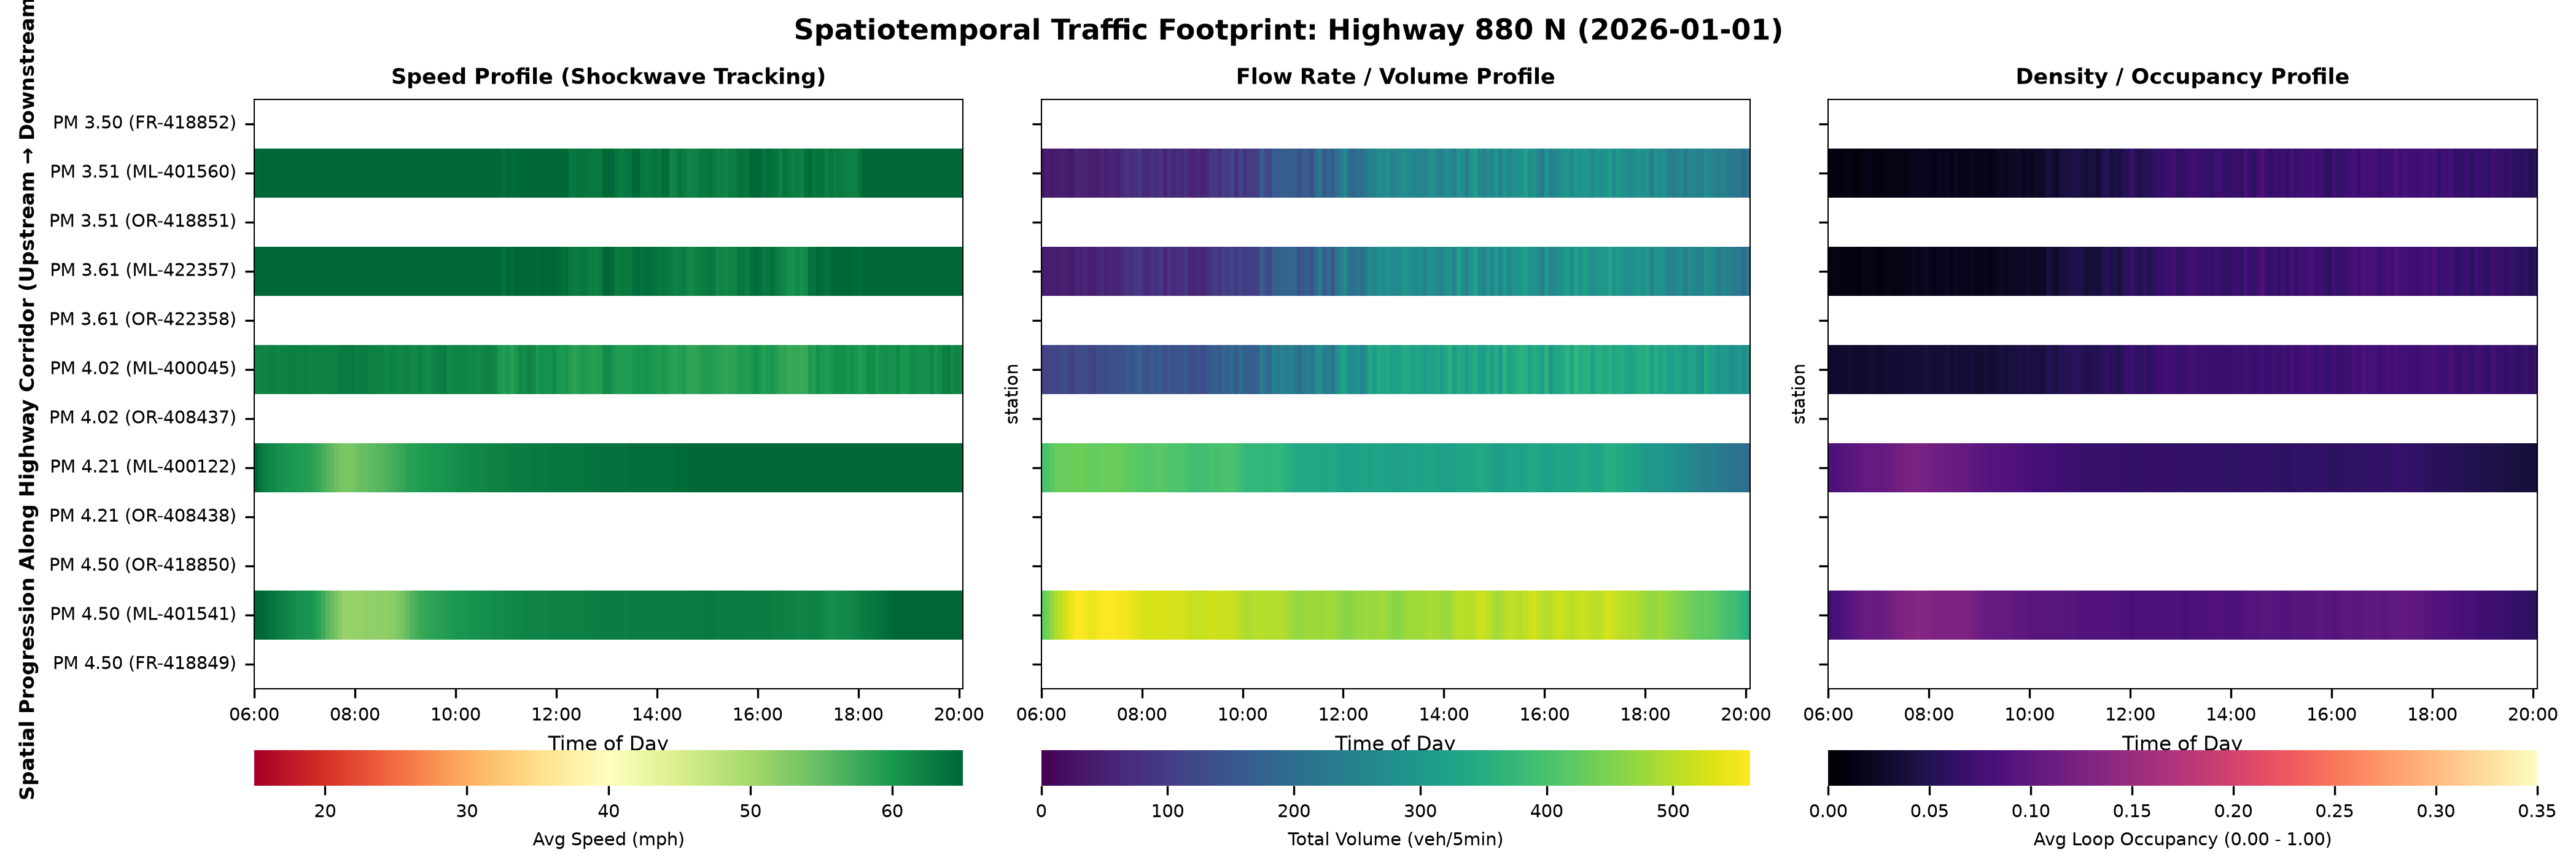

Plotting Space-Time Contours: Hwy 880 S (12 Stations)


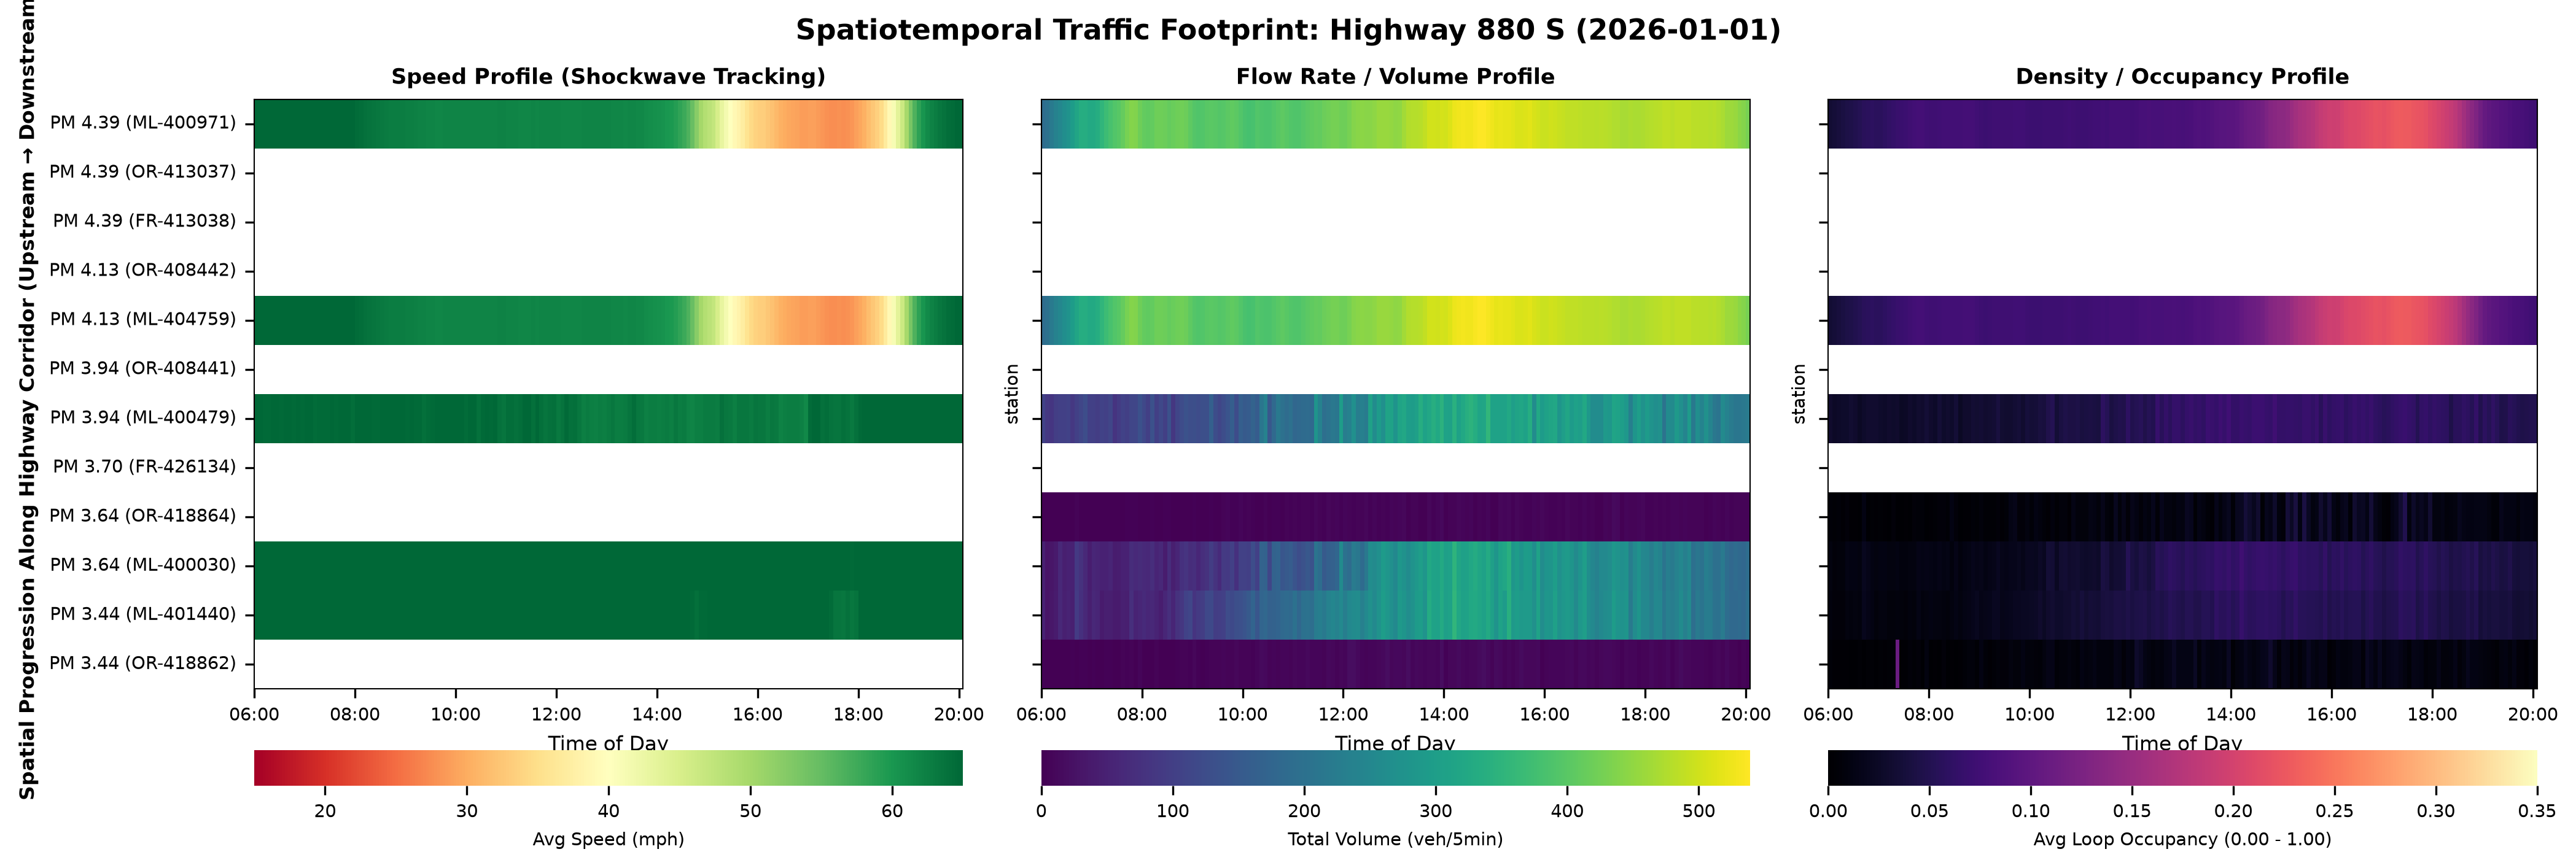

In [50]:
# ["total_flow", "avg_occupancy", "avg_speed"]
roi_stations_ids = region_df['ID'].values.tolist()
roi_filtered_df = data_df[data_df['station'].isin(roi_stations_ids)]
roi_flow_matrix = roi_filtered_df.pivot(
    index="timestamp",
    columns="station",
    values="total_flow"
)
roi_occupancy_matrix = roi_filtered_df.pivot(
    index="timestamp",
    columns="station",
    values="avg_occupancy"
)
roi_speed_flow_matrix = roi_filtered_df.pivot(
    index="timestamp",
    columns="station",
    values="avg_speed"
)

for matrix in [roi_speed_flow_matrix, roi_flow_matrix, roi_occupancy_matrix]:
    matrix.index = pd.to_datetime(matrix.index)

target_date = roi_speed_flow_matrix.index.strftime('%Y-%m-%d')[0]

start_time, end_time = '06:00', '20:00'

grouped_corridors = region_df.groupby(['Fwy', 'Dir'])
for (fwy, direction), corridor_meta in grouped_corridors:

    dir_str = str(direction).strip().upper()

    if dir_str == 'N':
        corridor_sorted = corridor_meta.sort_values(by='Abs_PM', ascending=True) 
    elif dir_str == 'S':
        corridor_sorted = corridor_meta.sort_values(by='Abs_PM', ascending=False)
    else:
        corridor_sorted = corridor_meta.sort_values(by='Abs_PM', ascending=True)
    
    ordered_station_ids = [sid for sid in corridor_sorted['ID'].values if sid in roi_speed_flow_matrix.columns]

    if not ordered_station_ids:
        print(f"Skipping: Hwy {fwy} Direction {direction} - No matching telemetry profiles found.")
        continue
    print(f"Plotting Space-Time Contours: Hwy {fwy} {dir_str} ({len(ordered_station_ids)} Stations)")
    
    # Slice target date and time frame windows, then transpose (.T) to place Space on the Y-Axis
    t_speed = roi_speed_flow_matrix[ordered_station_ids].loc[target_date].between_time(start_time, end_time).T
    t_flow = roi_flow_matrix[ordered_station_ids].loc[target_date].between_time(start_time, end_time).T
    t_occup = roi_occupancy_matrix[ordered_station_ids].loc[target_date].between_time(start_time, end_time).T

    y_axis_labels = []
    for sid in ordered_station_ids:
        row_meta = corridor_sorted[corridor_sorted['ID'] == sid].iloc[0]
        y_axis_labels.append(f"PM {row_meta['Abs_PM']:.2f} ({row_meta['Type']}-{sid})")

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 7

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True, dpi=300)
    
    sns.heatmap(t_speed, cmap='RdYlGn', vmin=15, vmax=65, ax=axes[0],
                cbar_kws={'label': 'Avg Speed (mph)', 'orientation': 'horizontal', 'pad': 0.08})
    axes[0].set_title("Speed Profile (Shockwave Tracking)", fontweight='bold')
    
    sns.heatmap(t_flow, cmap='viridis', vmin=0, vmax=t_flow.max().max(), ax=axes[1],
                cbar_kws={'label': 'Total Volume (veh/5min)', 'orientation': 'horizontal', 'pad': 0.08})
    axes[1].set_title("Flow Rate / Volume Profile", fontweight='bold')
    
    sns.heatmap(t_occup, cmap='magma', vmin=0.0, vmax=0.35, ax=axes[2],
                cbar_kws={'label': 'Avg Loop Occupancy (0.00 - 1.00)', 'orientation': 'horizontal', 'pad': 0.08})
    axes[2].set_title("Density / Occupancy Profile", fontweight='bold')
    
    time_ticks = [t.strftime('%H:%M') for t in t_speed.columns]
    tick_frequency = 12 * 2 
    
    for ax in axes:
        ax.set_xticks(np.arange(len(time_ticks))[::tick_frequency])
        ax.set_xticklabels(time_ticks[::tick_frequency], rotation=0, ha='center')
        ax.set_xlabel("Time of Day", fontsize=8, labelpad=4)
        
        for _, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.5)
            
    axes[0].set_yticklabels(y_axis_labels, rotation=0)
    axes[0].set_ylabel("Spatial Progression Along Highway Corridor (Upstream → Downstream)", fontsize=8, fontweight='bold')
    
    fig.suptitle(f"Spatiotemporal Traffic Footprint: Highway {fwy} {dir_str} ({target_date})", 
                 fontsize=11, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig(f"space_time_hwy_{fwy}_{dir_str}.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"space_time_hwy_{fwy}_{dir_str}.pdf", bbox_inches='tight')
    plt.show()
    

In [72]:
interchange_rows_101 = region_df[
    (region_df["Fwy"] == 101) & 
    (region_df["Name"].str.contains('880'))
]
interchange_rows_880 = region_df[
    (region_df["Fwy"] == 880) & 
    (region_df["Name"].str.contains('101'))
]

interchange_101_ids = interchange_rows_101['ID'].values.tolist()
interchange_101_df = data_df[data_df['station'].isin(interchange_101_ids)]

interchange_101_flow_mat = interchange_101_df.pivot(
    index='timestamp',
    columns='station',
    values="total_flow"
)
interchange_101_occupancy_mat = interchange_101_df.pivot(
    index='timestamp',
    columns='station',
    values="avg_occupancy"
)

interchange_101_speed_mat = interchange_101_df.pivot(
    index='timestamp',
    columns='station',
    values="avg_speed"
)

interchange_101_flow_mat.index = pd.to_datetime(interchange_101_flow_mat.index)
interchange_101_occupancy_mat.index = pd.to_datetime(interchange_101_occupancy_mat.index)
interchange_101_speed_mat.index = pd.to_datetime(interchange_101_speed_mat.index)

In [51]:
corridors = get_stations_near_roi(st_mtdta_df)
selected_ids = set()
for corridor_name, corridor_df in corridors.items():
    selected_ids.update(corridor_df['ID'].tolist())
selected_ids = list(selected_ids)

print(f"Total unique stations to extract data for: {len(selected_ids)}")
print(selected_ids)

params = ["total_flow", "avg_occupancy", "avg_speed"]

filtered_df = data_df[data_df['station'].isin(selected_ids)]

flow_mat = param_mat("total_flow", selected_ids, filtered_df)
occupancy_mat = param_mat("avg_occupancy", selected_ids, filtered_df)
speed_mat = param_mat("avg_speed", selected_ids, filtered_df)

58  Number of stations in this region.
Total unique stations to extract data for: 12
[401440, 400965, 401541, 400971, 400109, 400911, 422357, 401560, 402364, 402365, 400030, 400863]


<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_763/897481574.py:35: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel("Temporal Lag $\delta$ (Minutes: Upstream Future $\longleftrightarrow$ Upstream Past)", fontsize=8, labelpad=6)


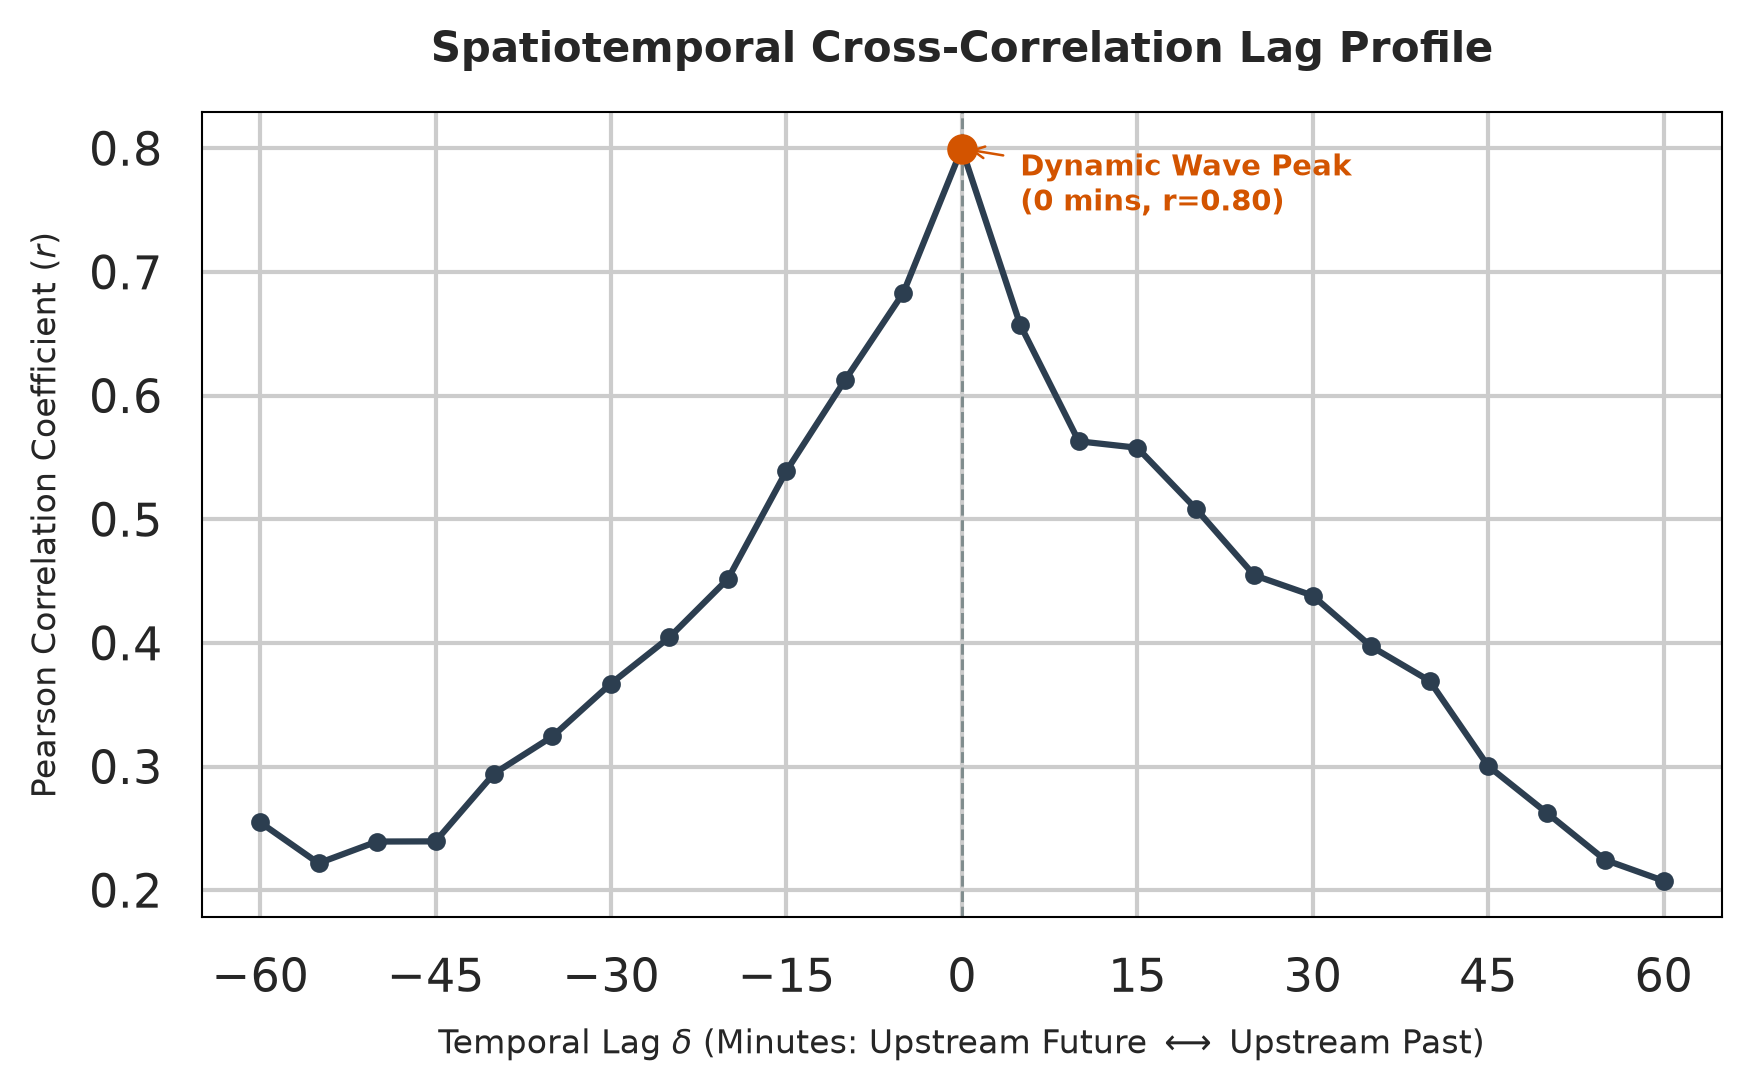

In [74]:

# make sure they are same Direction and Freeway
bottleneck_id = 400001  # 400001  NB 880 rm-n-loop   ML  387.897  37.364085 -121.901149
upstream_id = 400965 #  400965 NB Oakland Rd rm-n-diag  387.477

speed_mat.index = pd.to_datetime(speed_mat.index)
lags = np.arange(-12, 13)  
correlations = []

for lag in lags:
    shifted_upstream = speed_mat[upstream_id].shift(lag)
    corr = interchange_101_speed_mat[bottleneck_id].corr(shifted_upstream)
    correlations.append(corr)

lag_minutes = lags * 5

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 8
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "axes.linewidth": 0.5})

fig, ax = plt.subplots(figsize=(6, 3.8), dpi=300)

ax.plot(lag_minutes, correlations, color='#2c3e50', linewidth=1.5, marker='o', markersize=3.5, label='Traffic Speed')
peak_idx = np.argmax(np.abs(correlations))
peak_lag = lag_minutes[peak_idx]
peak_corr = correlations[peak_idx]

ax.scatter(peak_lag, peak_corr, color='#d35400', s=40, zorder=5)
ax.annotate(f"Dynamic Wave Peak\n({peak_lag} mins, r={peak_corr:.2f})",
            xy=(peak_lag, peak_corr),
            xytext=(peak_lag + 5, peak_corr - 0.05 if peak_corr > 0 else peak_corr + 0.05),
            fontsize=7, fontweight='bold', color='#d35400',
            arrowprops=dict(arrowstyle="->", color='#d35400', linewidth=0.6))

ax.set_title("Spatiotemporal Cross-Correlation Lag Profile", fontsize=10, fontweight='bold', pad=12)
ax.set_xlabel("Temporal Lag $\delta$ (Minutes: Upstream Future $\longleftrightarrow$ Upstream Past)", fontsize=8, labelpad=6)
ax.set_ylabel("Pearson Correlation Coefficient ($r$)", fontsize=8, labelpad=6)
ax.axvline(x=0, color='#7f8c8d', linestyle='--', linewidth=0.7)
ax.set_xlim(-65, 65)
ax.set_xticks(np.arange(-60, 61, 15))
# print(correlations)
plt.tight_layout()
# plt.savefig('phase3_cross_correlation.png', bbox_inches='tight', dpi=300)
plt.show()